### Setup (Optional)

**What this cell does:** Shows optional commands to clone the course repository and install required packages.

**What we learn/functionality:** How to prepare the environment when running the notebook on a fresh machine (for example, Colab).

In [8]:
# Optional setup commands for fresh environments (keep commented in local runs).
# !git clone https://github.com/recepgul82/music-digital-methods.git
# !pip install -r music-digital-methods/setup/requirements.txt


**The cell below is only for logistics. Just run it and disregard**

### Project Path Setup

**What this cell does:** Detects the repository root dynamically, prints it, and adds it to `sys.path` so local modules can be imported.

**What we learn/functionality:** How to make notebooks portable across different folder structures without hardcoding absolute paths.

In [9]:
# Import utilities for dynamic path detection and Python module path updates.
import sys
from pathlib import Path


def find_repo_root(marker_dir="course_code"):
    # Search upward from the current working directory first.
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / marker_dir).is_dir():
            return p
        if p == p.parent:
            break
        p = p.parent

    # Fallback: scan common roots (e.g., Colab /content) for the marker directory.
    for base in [Path("/content"), Path.cwd().resolve()]:
        if base.exists():
            for candidate in base.rglob(marker_dir):
                if candidate.is_dir():
                    return candidate.parent

    raise RuntimeError(f"Could not locate repo root containing '{marker_dir}/'.")


# Resolve repository root and make local package imports available.
REPO_ROOT = find_repo_root("course_code")
print("REPO_ROOT =", REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))



REPO_ROOT = /Users/recepgul/Desktop/ITU/Teaching/Doktora/LEE904E/music-digital-methods


1. Load Data

### Load and Merge Lyrics Data

**What this cell does:** Reads all artist CSV files, concatenates them into one DataFrame, drops missing lyrics, and normalizes column names.

**What we learn/functionality:** How to build a clean unified dataset from multiple files for text analysis.

In [10]:
# Load all per-artist CSV lyric files and combine into a single analysis table.
import pandas as pd
from pathlib import Path

# Folder containing lyric CSV files.
data_path = REPO_ROOT / "data/song_lyrics/csv"

dfs = []
for file in data_path.glob("*.csv"):
    # Read each artist file; first column is an index column in these files.
    df = pd.read_csv(file, index_col=0)
    dfs.append(df)

# Merge all files into one DataFrame and clean key fields.
lyrics_df = pd.concat(dfs, ignore_index=True)
lyrics_df = lyrics_df.dropna(subset=["Lyric"])
lyrics_df.columns = lyrics_df.columns.str.lower()  # Normalize to lowercase column names.
lyrics_df.head()



,artist,title,album,year,date,lyric
0,Dua Lipa,New Rules,Dua Lipa,2017.0,2017-06-02,one one one one one talkin' in my sleep at n...
1,Dua Lipa,Don’t Start Now,Future Nostalgia,2019.0,2019-11-01,if you don't wanna see me did a full 80 craz...
2,Dua Lipa,IDGAF,Dua Lipa,2017.0,2017-06-02,you call me all friendly tellin' me how much y...
3,Dua Lipa,Blow Your Mind (Mwah),Dua Lipa,2016.0,2016-08-26,i know it's hot i know we've got something tha...
4,Dua Lipa,Be the One,Dua Lipa,2015.0,2015-10-30,i see the moon i see the moon i see the moon o...


2. Simple EDA

### Artist Distribution Check

**What this cell does:** Counts songs per artist and returns the total number of records.

**What we learn/functionality:** A quick quality check for class balance and dataset size.

In [11]:
# Count how many songs each artist has and the total number of rows.
lyrics_df["artist"].value_counts(), lyrics_df["artist"].value_counts().sum()



(artist
 Eminem           521
 Taylor Swift     477
 Drake            464
 Beyoncé          406
 Rihanna          397
 Lady Gaga        395
 Justin Bieber    347
 Coldplay         333
 Katy Perry       324
 Nicki Minaj      321
 Ed Sheeran       294
 BTS (방탄소년단)      270
 Dua Lipa         246
 Maroon 5         197
 Selena Gomez     174
 Post Malone      148
 Billie Eilish    145
 Charlie Puth      75
 Cardi B           75
 Khalid            64
 Name: count, dtype: int64,
 np.int64(5673))

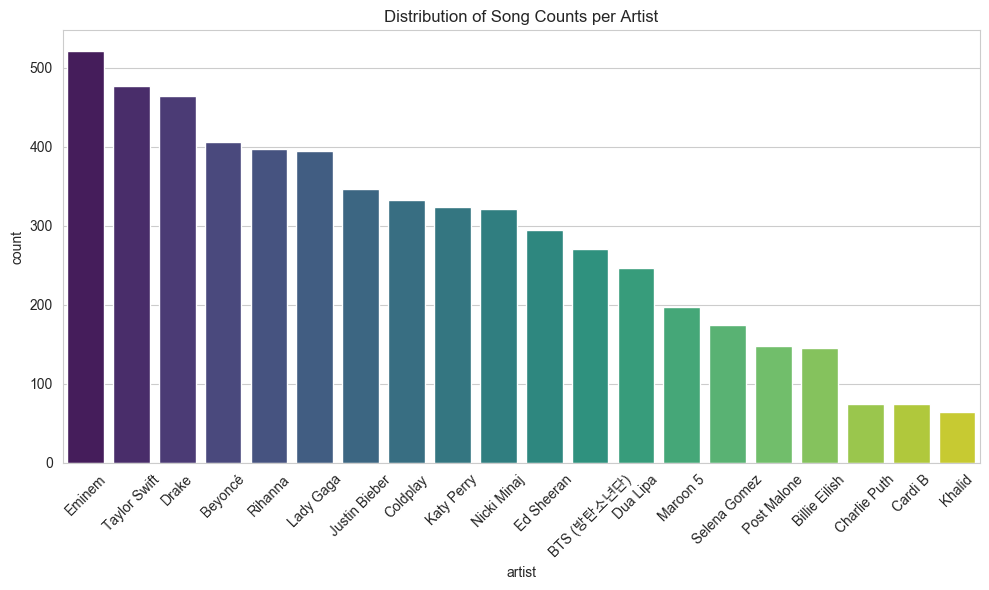

In [28]:
import seaborn as sns 
import matplotlib.pyplot as plt

#TODO: visualize the distribution of song counts per artist using a bar plot.
sns.set_style("whitegrid") # Set a clean style for better aesthetics
plt.figure(figsize=(10, 6)) # set figure size for better readability
plt.rcParams["font.family"] = "Arial Unicode MS" # Set font to support Korean characters (adjust if needed for your environment)
plt.rcParams["axes.unicode_minus"] = False 

order = lyrics_df['artist'].value_counts().index # sort artists by song count before plotting
palette = dict(
    zip(order, sns.color_palette("viridis", len(order)))
) # Create a color palette mapping each artist to a unique color

sns.countplot(x='artist', 
              data=lyrics_df, 
              order=order, 
              hue="artist", 
              palette=palette,
              legend=False
              )  
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability if there are many artists
plt.title('Distribution of Song Counts per Artist')

plt.tight_layout()

### Lyric Length Analysis

**What this cell does:** Computes lyric word counts and average lyric length by artist.

**What we learn/functionality:** How descriptive statistics reveal stylistic differences among artists.

In [5]:
# Compute lyric length statistics (word count per song, then artist averages).
lyrics_df["lyric_length"] = lyrics_df["lyric"].str.split().str.len()

avg_length = (
    lyrics_df
    .groupby("artist")["lyric_length"]
    .mean()
    .sort_values(ascending=False)
)

avg_length



artist
Eminem           668.284069
BTS (방탄소년단)      504.214815
Drake            469.851293
Cardi B          424.733333
Nicki Minaj      414.959502
Beyoncé          410.699507
Post Malone      393.783784
Ed Sheeran       377.843537
Rihanna          368.614610
Maroon 5         337.989848
Lady Gaga        330.589873
Khalid           326.343750
Taylor Swift     322.262055
Charlie Puth     316.813333
Justin Bieber    315.345821
Dua Lipa         311.426829
Selena Gomez     274.413793
Katy Perry       265.509259
Billie Eilish    199.662069
Coldplay         188.801802
Name: lyric_length, dtype: float64

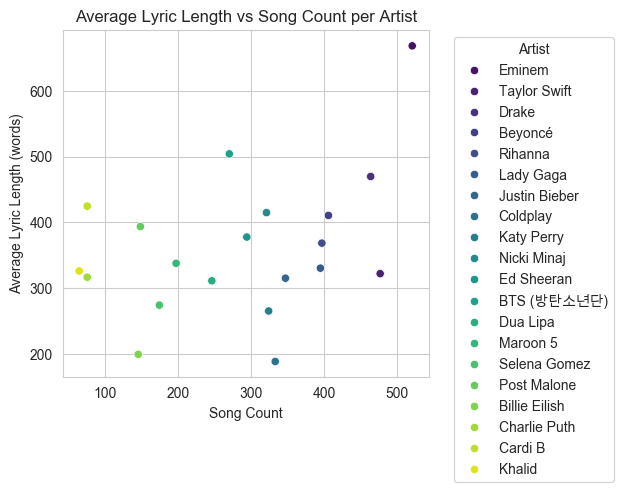

In [29]:
# Create a scatter plot per artist for avg_length vs song count.
artist_counts = lyrics_df["artist"].value_counts()
artist_stats = pd.DataFrame({
    "artist": artist_counts.index,
    "song_count": artist_counts.values,
    "avg_length": avg_length[artist_counts.index].values
})  
sns.scatterplot(data=artist_stats, x="song_count", y="avg_length", hue="artist", palette=palette)
plt.title("Average Lyric Length vs Song Count per Artist")
plt.xlabel("Song Count")
plt.ylabel("Average Lyric Length (words)")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside the plot
plt.tight_layout()  

### Vocabulary Richness (TTR)

**What this cell does:** Calculates per-artist vocabulary size, total token count, and type-token ratio (TTR).

**What we learn/functionality:** How lexical diversity can be measured to compare writing style complexity.

In [30]:
# Measure lexical richness per artist using vocabulary size and TTR.
artist_stats = lyrics_df.groupby("artist").agg(
    vocab_size=("lyric", lambda x: len(set(" ".join(x).split()))),
    total_tokens=("lyric", lambda x: len(" ".join(x).split())),
)

# Type-token ratio = unique words / total words.
artist_stats["ttr"] = artist_stats["vocab_size"] / artist_stats["total_tokens"]
artist_stats.sort_values("ttr", ascending=False)



,vocab_size,total_tokens,ttr
artist,,,
BTS (방탄소년단),21158,136138,0.155416
Cardi B,3319,31855,0.104191
Khalid,1820,20886,0.087140
Nicki Minaj,9699,133202,0.072814
Charlie Puth,1643,23761,0.069147
Post Malone,3901,58280,0.066935
Billie Eilish,1915,28951,0.066146
Eminem,21812,348176,0.062646
Coldplay,3520,62871,0.055988


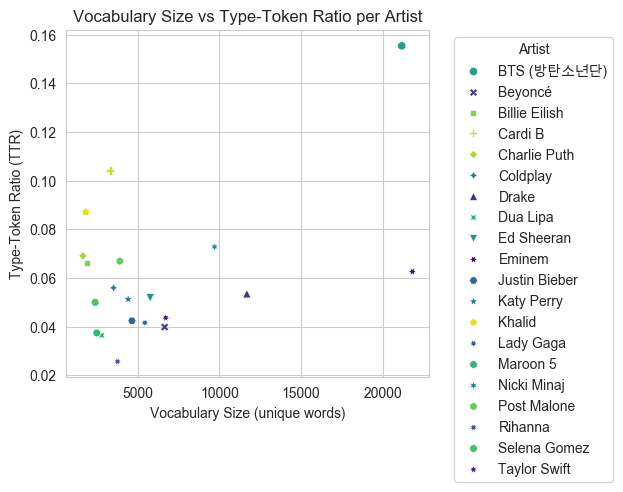

In [33]:
# visualize the relationship between vocabulary size and TTR across artists.
# use different shapes or colors for each artist to distinguish them in the scatter plot.
sns.scatterplot(
    data=artist_stats,
    x="vocab_size",
    y="ttr",
    hue=artist_stats.index,
    style=artist_stats.index,
    palette=palette
)

plt.title("Vocabulary Size vs Type-Token Ratio per Artist")
plt.xlabel("Vocabulary Size (unique words)")
plt.ylabel("Type-Token Ratio (TTR)")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

3. Text Preprocessing

### Import Preprocessing Tools

**What this cell does:** Imports NLP tools for stopword removal, lemmatization, and regex-based cleaning.

**What we learn/functionality:** The core toolkit needed before text normalization.

In [34]:
# Import NLP preprocessing libraries.
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re



### Download NLTK Resources

**What this cell does:** Downloads required NLTK corpora (`stopwords`, `wordnet`).

**What we learn/functionality:** Some NLP resources must be downloaded once before use.

In [35]:
# Download required NLTK resources (run once per environment).
nltk.download("stopwords")
nltk.download("wordnet")



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/recepgul/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/recepgul/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Initialize Preprocessing Objects

**What this cell does:** Builds the English stopword set and initializes a WordNet lemmatizer.

**What we learn/functionality:** How reusable preprocessing components are prepared for pipeline functions.

In [36]:
# Prepare reusable stopword set and lemmatizer objects.
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()



### Define Preprocessing Function

**What this cell does:** Defines a function that lowercases text, removes punctuation/non-letters, tokenizes, removes stopwords, and lemmatizes.

**What we learn/functionality:** How to compose a standard NLP cleaning pipeline in one reusable function.

In [37]:
# Define a text-cleaning pipeline for lyrics.
def preprocess(text):
    # Lowercase for case-insensitive matching.
    text = text.lower()
    # Keep letters and whitespace only.
    text = re.sub(r"[^a-z\s]", "", text)
    # Tokenize by whitespace.
    tokens = text.split()
    # Remove common stopwords.
    tokens = [w for w in tokens if w not in stop_words]
    # Lemmatize tokens to base forms.
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens



### Apply Preprocessing

**What this cell does:** Applies `preprocess` to each lyric and stores both tokenized and joined cleaned text versions.

**What we learn/functionality:** How to create both token-level and document-level representations for later models.

In [38]:
# Apply preprocessing to each lyric and create token/text representations.
lyrics_df["clean_tokens"] = lyrics_df["lyric"].apply(preprocess)
lyrics_df["clean_text"] = lyrics_df["clean_tokens"].apply(lambda x: " ".join(x))



### Inspect Original vs Cleaned Text

**What this cell does:** Expands column display and shows one row with raw and cleaned text side by side.

**What we learn/functionality:** Visual validation of preprocessing quality before modeling.

In [39]:
# Show one row to compare original and cleaned lyric text.
import pandas as pd
from IPython.display import display

# Avoid truncating long lyric text during display.
pd.set_option("display.max_colwidth", None)

display(lyrics_df[["artist", "title", "lyric", "clean_text"]].iloc[[0]])



,artist,title,lyric,clean_text
0,Dua Lipa,New Rules,one one one one one talkin' in my sleep at night makin' myself crazy out of my mind out of my mind wrote it down and read it out hopin' it would save me too many times too many times refrain my love he makes me feel like nobody else nobody else but my love he doesn't love me so i tell myself i tell myself pre one don't pick up the phone you know he's only callin' 'cause he's drunk and alone two don't let him in you'll have to kick him out again three don't be his friend you know you're gonna wake up in his bed in the morning and if you're under him you ain't gettin' over him i got new rules i count 'em i got new rules i count 'em i gotta tell them to myself i got new rules i count 'em i gotta tell them to myself i keep pushin' forwards but he keeps pullin' me backwards nowhere to turn no way nowhere to turn no now i'm standin' back from it i finally see the pattern i never learn i never learn refrain but my love he doesn't love me so i tell myself i tell myself i do i do i do pre one don't pick up the phone you know he's only callin' 'cause he's drunk and alone two don't let him in you'll have to kick him out again three don't be his friend you know you're gonna wake up in his bed in the morning and if you're under him you ain't gettin' over him i got new rules i count 'em i got new rules i count 'em i gotta tell them to myself i got new rules i count 'em i gotta tell them to myself practice makes perfect i'm still tryna learn it by heart i got new rules i count 'em eat sleep and breathe it rehearse and repeat it 'cause i i got new pre one don't pick up the phone yeah you know he's only callin' 'cause he's drunk and alone alone two don't let him in uhooh you'll have to kick him out again again three don't be his friend you know you're gonna wake up in his bed in the morning and if you're under him you ain't gettin' over him i got new rules i count 'em i got new rules i count 'em whoaooh whoaooh whoa i gotta tell them to myself i got new rules i count 'em baby you know i count 'em i gotta tell them to myself don't let him in don't let him in don't don't don't don't don't be his friend don't be his friend don't don't don't don't don't let him in don't let him in don't don't don't don't don't be his friend don't be his friend don't don't don't don't you're gettin' over him,one one one one one talkin sleep night makin crazy mind mind wrote read hopin would save many time many time refrain love make feel like nobody else nobody else love doesnt love tell tell pre one dont pick phone know he callin cause he drunk alone two dont let youll kick three dont friend know youre gonna wake bed morning youre aint gettin got new rule count em got new rule count em gotta tell got new rule count em gotta tell keep pushin forward keep pullin backwards nowhere turn way nowhere turn im standin back finally see pattern never learn never learn refrain love doesnt love tell tell pre one dont pick phone know he callin cause he drunk alone two dont let youll kick three dont friend know youre gonna wake bed morning youre aint gettin got new rule count em got new rule count em gotta tell got new rule count em gotta tell practice make perfect im still tryna learn heart got new rule count em eat sleep breathe rehearse repeat cause got new pre one dont pick phone yeah know he callin cause he drunk alone alone two dont let uhooh youll kick three dont friend know youre gonna wake bed morning youre aint gettin got new rule count em got new rule count em whoaooh whoaooh whoa gotta tell got new rule count em baby know count em gotta tell dont let dont let dont dont dont dont dont friend dont friend dont dont dont dont dont let dont let dont dont dont dont dont friend dont friend dont dont dont dont youre gettin


### Inspect Token Output

**What this cell does:** Prints the first 40 cleaned tokens from the first lyric.

**What we learn/functionality:** A quick sanity check that tokenization and lemmatization behave as expected.

In [40]:
# Print a token preview for quick preprocessing validation.
print("TOKENS AFTER PREPROCESSING:\n")
print(lyrics_df.iloc[0]["clean_tokens"][:40])



TOKENS AFTER PREPROCESSING:

['one', 'one', 'one', 'one', 'one', 'talkin', 'sleep', 'night', 'makin', 'crazy', 'mind', 'mind', 'wrote', 'read', 'hopin', 'would', 'save', 'many', 'time', 'many', 'time', 'refrain', 'love', 'make', 'feel', 'like', 'nobody', 'else', 'nobody', 'else', 'love', 'doesnt', 'love', 'tell', 'tell', 'pre', 'one', 'dont', 'pick', 'phone']


4. Bag-of-Words

### Build Bag-of-Words Matrix

**What this cell does:** Vectorizes cleaned lyrics into a term-frequency matrix and converts it to a DataFrame.

**What we learn/functionality:** How text is transformed into numeric features for analysis.

In [41]:
# Build a Bag-of-Words representation from cleaned lyrics.
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(lyrics_df["clean_text"])

# Convert sparse matrix to a readable DataFrame (rows=songs, columns=terms).
bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=lyrics_df.index,
)

bow_df.head()



,aa,aaaa,aaaaaaack,aaaaaaah,aaaaah,aaaaayyyyooooo,aaaahh,aaaalalalalalchemist,aaaayo,aaagain,...,zutto,zuzu,zvednte,zwrotka,zwycizc,zy,zyska,zz,zzzero,zzzzzone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### View Non-Zero Terms for One Song

**What this cell does:** Displays only words that appear in the first lyric.

**What we learn/functionality:** How sparse BoW vectors map to real words in a single document.

In [42]:
# Inspect non-zero BoW terms for the first song only.
bow_df.iloc[[0]].loc[:, bow_df.iloc[0] > 0]



,aint,alone,baby,back,backwards,bed,breathe,callin,cause,count,...,uhooh,wake,way,whoa,whoaooh,would,wrote,yeah,youll,youre
0,3,4,1,1,1,3,1,3,4,11,...,1,3,1,1,2,1,1,1,3,7


### Global Frequent Words

**What this cell does:** Sums term counts across all songs and shows the most frequent words.

**What we learn/functionality:** How to identify dominant vocabulary in the full corpus.

In [43]:
# Aggregate term counts across all songs and show top words.
word_counts = bow_df.sum(axis=0).sort_values(ascending=False)
print(bow_df.shape)
word_counts.head(20)



(5981, 37226)


im       26959
like     18238
dont     17419
know     15276
love     14459
yeah     13603
oh       13134
got      10520
get      10421
baby      9392
go        9021
cause     8898
let       8441
youre     8436
want      8201
one       7867
wanna     6701
back      6527
girl      6463
time      6446
dtype: int64

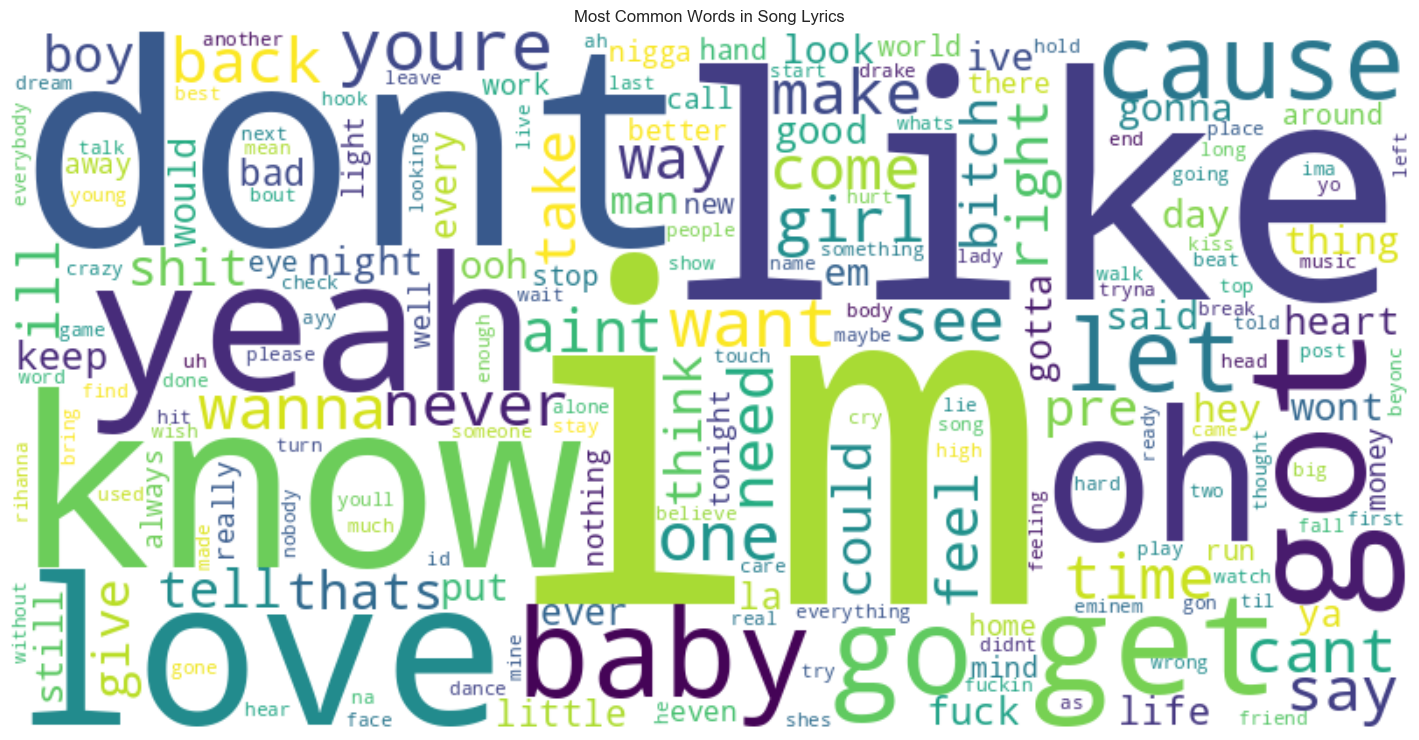

In [44]:
# Visualize most common words as word cloud.
from wordcloud import WordCloud
# Generate a word cloud from the aggregated word counts.
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)
# Display the generated word cloud.
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Song Lyrics")
plt.tight_layout()

### Artist-Specific Frequent Words

**What this cell does:** Filters BoW rows for one artist and computes their most common words.

**What we learn/functionality:** How to compare vocabulary usage at artist level.

In [45]:
# Compute most frequent BoW terms for a selected artist.
artist = "Dua Lipa"
artist_bow = bow_df[lyrics_df["artist"] == artist]
artist_counts = artist_bow.sum(axis=0).sort_values(ascending=False)
artist_counts.head(15)



dont     1304
im        883
know      631
got       596
love      572
let       568
like      546
cause     500
youre     493
come      463
one       462
get       458
baby      425
yeah      417
pre       343
dtype: int64

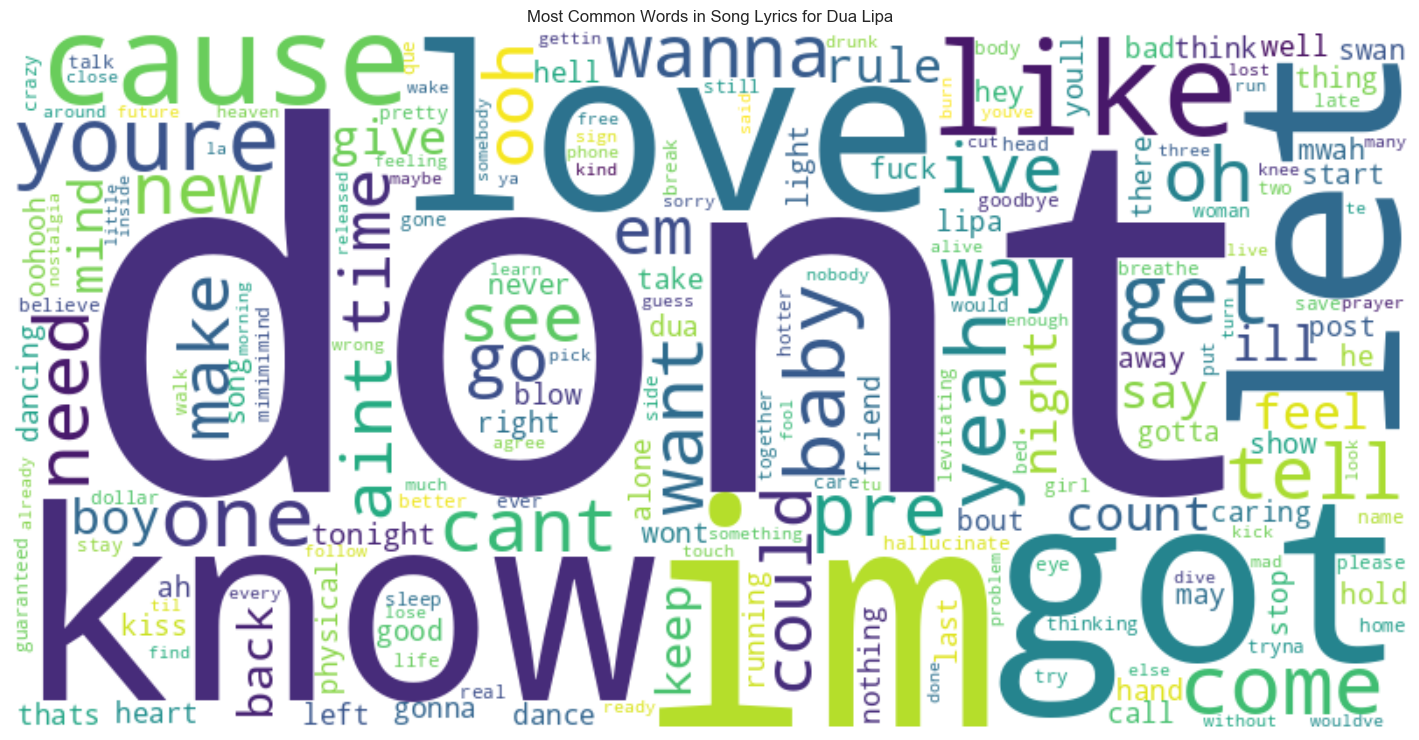

In [46]:
wordcloud_artist = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(artist_counts)
# Display the generated word cloud.
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud_artist, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Song Lyrics for Dua Lipa")
plt.tight_layout()

5. Bigram Analysis

### Bigram Frequency Analysis

**What this cell does:** Builds a bigram vectorizer and lists the most frequent two-word phrases.

**What we learn/functionality:** How n-grams capture local phrase patterns beyond single words.

In [47]:
# Build bigram counts to analyze common two-word phrases.
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_bigram = bigram_vectorizer.fit_transform(lyrics_df["clean_text"])

bigram_counts = pd.DataFrame(
    X_bigram.sum(axis=0).A1,
    index=bigram_vectorizer.get_feature_names_out(),
    columns=["count"],
)

bigram_counts.sort_values("count", ascending=False).head(20)



,count
oh oh,3436
yeah yeah,3391
let go,2019
la la,1946
dont know,1845
love love,1719
dont wanna,1667
know know,1237
feel like,1191
know im,1029


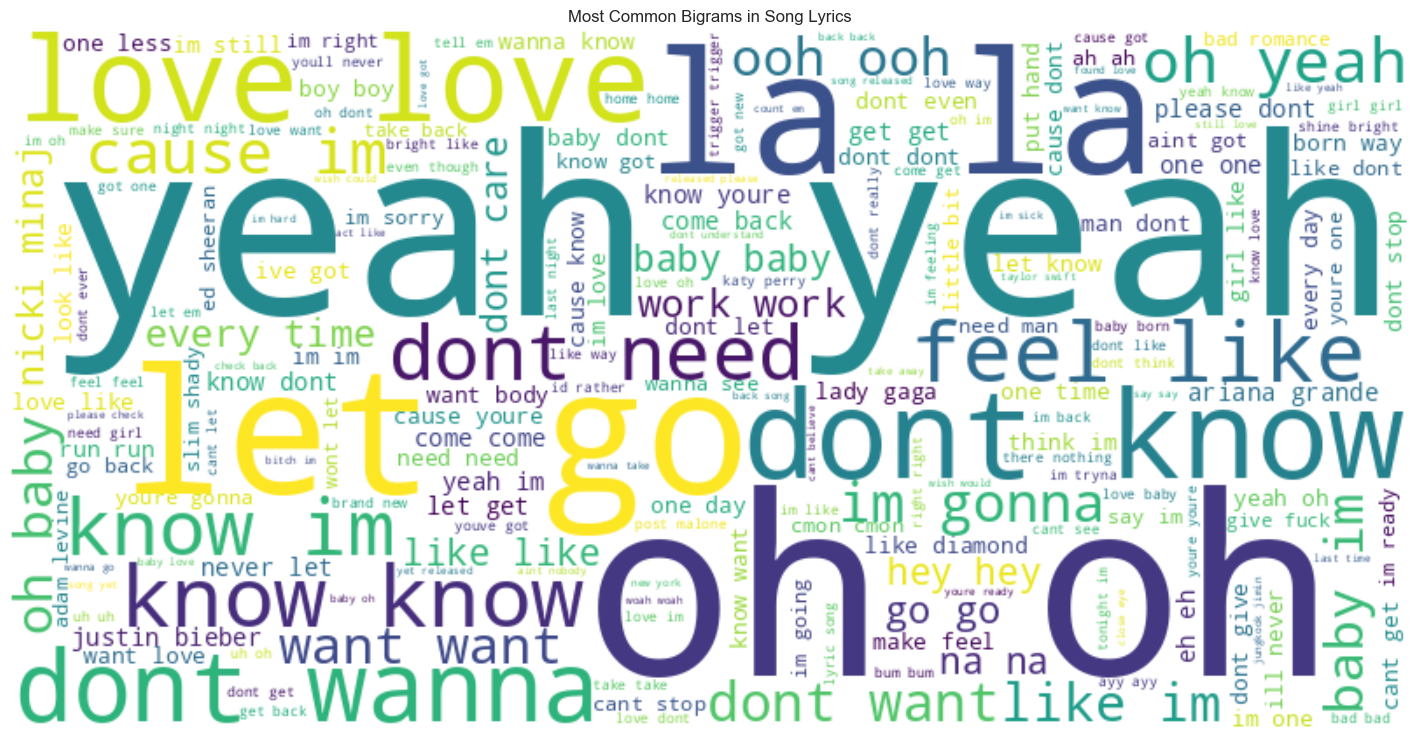

In [48]:
# Build a bigram word cloud to visualize common two-word phrases.
bigram_wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(bigram_counts["count"])
plt.figure(figsize=(15, 7.5))
plt.imshow(bigram_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Bigrams in Song Lyrics")
plt.tight_layout()

6. TF-IDF

### Compute TF-IDF Features

**What this cell does:** Creates a TF-IDF representation of cleaned lyrics.

**What we learn/functionality:** How to weight words by importance instead of raw frequency.

In [49]:
# Build TF-IDF features to weight informative words higher than common words.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(lyrics_df["clean_text"])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out(),
)



# Analysis Tasks

## 1. Words that Describe Artists

### Average TF-IDF by Artist

**What this cell does:** Adds artist labels and averages TF-IDF scores per artist.

**What we learn/functionality:** How to derive representative term profiles for each artist.

In [50]:
# Add artist labels and compute mean TF-IDF profile per artist.
tfidf_df["artist"] = lyrics_df["artist"].values
artist_tfidf = tfidf_df.groupby("artist").mean()


### Top TF-IDF Terms per Artist

**What this cell does:** Prints the top 5 highest-TF-IDF words for each artist profile.

**What we learn/functionality:** Which words are most characteristic for each artist.

In [ ]:
# Print top TF-IDF terms that characterize each artist.
for artist in artist_tfidf.index:
    print("\n", artist)
    print(artist_tfidf.loc[artist].sort_values(ascending=False).head(5))



 BTS (방탄소년단)
jungkook    0.129414
jimin       0.108789
jin         0.073783
rm          0.068807
jhope       0.055478
Name: BTS (방탄소년단), dtype: float64

 Beyoncé
beyonc    0.057212
love      0.053695
im        0.042769
oh        0.038495
baby      0.036313
Name: Beyoncé, dtype: float64

 Billie Eilish
ocean    0.068473
im       0.054355
dont     0.051413
eye      0.044295
like     0.038793
Name: Billie Eilish, dtype: float64

 Cardi B
bitch    0.128176
cardi    0.116238
nigga    0.066088
like     0.057365
im       0.056235
Name: Cardi B, dtype: float64

 Charlie Puth
charlie    0.079740
puth       0.075581
oh         0.062626
baby       0.061834
dont       0.054350
Name: Charlie Puth, dtype: float64

 Coldplay
oh       0.059189
dont     0.033025
light    0.028574
world    0.027882
im       0.027757
Name: Coldplay, dtype: float64

 Drake
drake    0.080011
im       0.077595
nigga    0.069104
know     0.057073
like     0.053281
Name: Drake, dtype: float64

 Dua Lipa
dont        0.068407


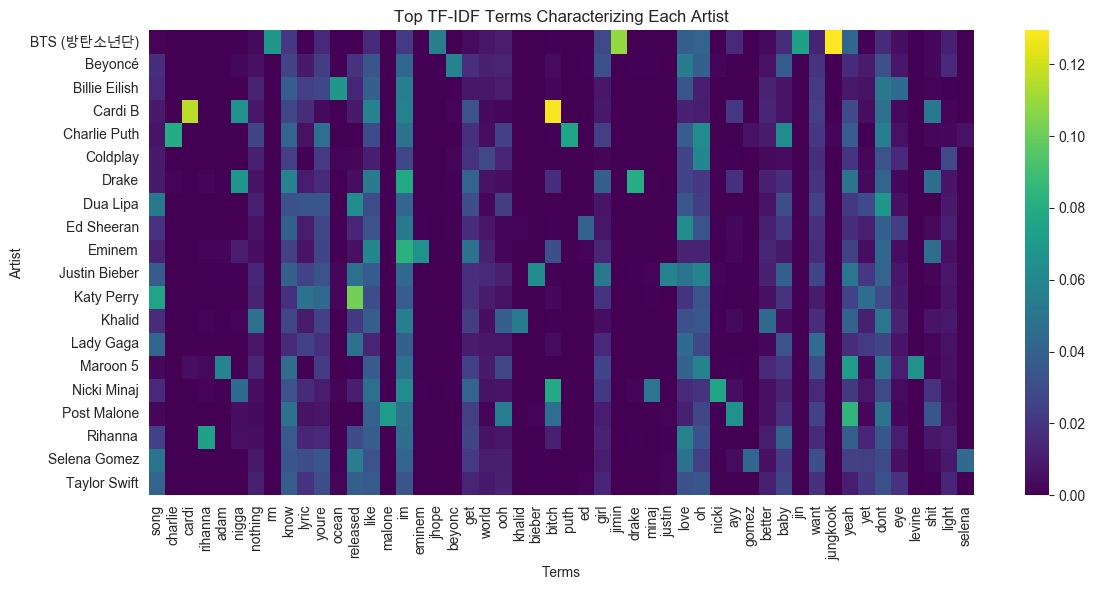

In [55]:
# Number of top TF-IDF terms to extract per artist
top_n = 5

# Create a set to store unique top terms across all artists
top_terms = set()

# For each artist, find the top TF-IDF terms and add them to the set
for artist in artist_tfidf.index:
    top_terms.update(
        artist_tfidf.loc[artist]              # Select TF-IDF vector for the artist
        .sort_values(ascending=False)         # Sort terms by TF-IDF score
        .head(top_n)                          # Take top N terms
        .index                                # Extract term names
    )

# Convert the set to a list so it can be used for indexing
top_terms = list(top_terms)

# Subset the TF-IDF matrix to include only the selected top terms
tfidf_top = artist_tfidf[top_terms]

# Create a figure for the heatmap
plt.figure(figsize=(12,6))

# Plot heatmap showing TF-IDF strength of selected terms for each artist
sns.heatmap(
    tfidf_top,
    cmap="viridis",      # Color map representing TF-IDF intensity
    annot=False,         # Do not display numeric values inside cells
    fmt=".2f"            # Formatting if annotations are enabled
)

# Add plot title and axis labels
plt.title("Top TF-IDF Terms Characterizing Each Artist")
plt.xlabel("Terms")
plt.ylabel("Artist")

# Adjust layout so labels and titles fit properly
plt.tight_layout()

## 2. Artist Similarity

### Build Artist-Level Documents

**What this cell does:** Concatenates all cleaned lyrics per artist into one document each.

**What we learn/functionality:** How to move from song-level to artist-level similarity analysis.

In [56]:
# Concatenate all cleaned lyrics into one document per artist.
artist_docs = lyrics_df.groupby("artist")["clean_text"].apply(lambda x: " ".join(x))


### Vectorize Artist Documents

**What this cell does:** Fits TF-IDF on artist-level documents to produce an artist-feature matrix.

**What we learn/functionality:** How to represent each artist as a vector in shared term space.

In [57]:
# Vectorize artist-level documents with TF-IDF.
tfidf_artist = TfidfVectorizer()
artist_matrix = tfidf_artist.fit_transform(artist_docs)



### Compute Artist Similarity

**What this cell does:** Computes cosine similarity between artist vectors and displays a similarity matrix.

**What we learn/functionality:** How numerically similar artists are based on lyrical language.

In [58]:
# Compute cosine similarity between artist TF-IDF vectors.
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(artist_matrix)
sim_df = pd.DataFrame(sim, index=artist_docs.index, columns=artist_docs.index)
sim_df



artist,BTS (방탄소년단),Beyoncé,Billie Eilish,Cardi B,Charlie Puth,Coldplay,Drake,Dua Lipa,Ed Sheeran,Eminem,Justin Bieber,Katy Perry,Khalid,Lady Gaga,Maroon 5,Nicki Minaj,Post Malone,Rihanna,Selena Gomez,Taylor Swift
artist,,,,,,,,,,,,,,,,,,,,
BTS (방탄소년단),1.000000,0.387773,0.301322,0.230015,0.325911,0.357540,0.342387,0.340787,0.358709,0.308963,0.384859,0.352051,0.322992,0.329173,0.356410,0.302126,0.336769,0.358230,0.330229,0.369209
Beyoncé,0.387773,1.000000,0.646166,0.510958,0.672776,0.704431,0.727250,0.740246,0.755490,0.695287,0.768038,0.737385,0.655396,0.690259,0.683283,0.677052,0.647789,0.743482,0.691014,0.774126
Billie Eilish,0.301322,0.646166,1.000000,0.477382,0.597594,0.592614,0.675494,0.702519,0.706389,0.671998,0.639500,0.677378,0.647880,0.596465,0.614239,0.599589,0.589439,0.622814,0.603478,0.728498
Cardi B,0.230015,0.510958,0.477382,1.000000,0.426141,0.406038,0.661434,0.509747,0.502399,0.635211,0.473641,0.498456,0.470717,0.428709,0.481915,0.700690,0.634249,0.516458,0.439750,0.490262
Charlie Puth,0.325911,0.672776,0.597594,0.426141,1.000000,0.631484,0.628431,0.697219,0.660647,0.592483,0.705847,0.691030,0.618243,0.618450,0.647325,0.546558,0.597477,0.650629,0.621930,0.699170
Coldplay,0.357540,0.704431,0.592614,0.406038,0.631484,1.000000,0.615228,0.665872,0.705857,0.601991,0.696659,0.691591,0.637485,0.607910,0.664860,0.552972,0.590637,0.644431,0.625596,0.746915
Drake,0.342387,0.727250,0.675494,0.661434,0.628431,0.615228,1.000000,0.711324,0.732511,0.810231,0.717215,0.713264,0.675305,0.605851,0.687520,0.798947,0.761050,0.710363,0.646766,0.744592
Dua Lipa,0.340787,0.740246,0.702519,0.509747,0.697219,0.665872,0.711324,1.000000,0.761636,0.694621,0.733059,0.746988,0.704894,0.676597,0.697714,0.644915,0.682574,0.712050,0.680508,0.758989
Ed Sheeran,0.358709,0.755490,0.706389,0.502399,0.660647,0.705857,0.732511,0.761636,1.000000,0.711221,0.747865,0.727646,0.718482,0.690052,0.711516,0.644636,0.641663,0.720972,0.697446,0.811408


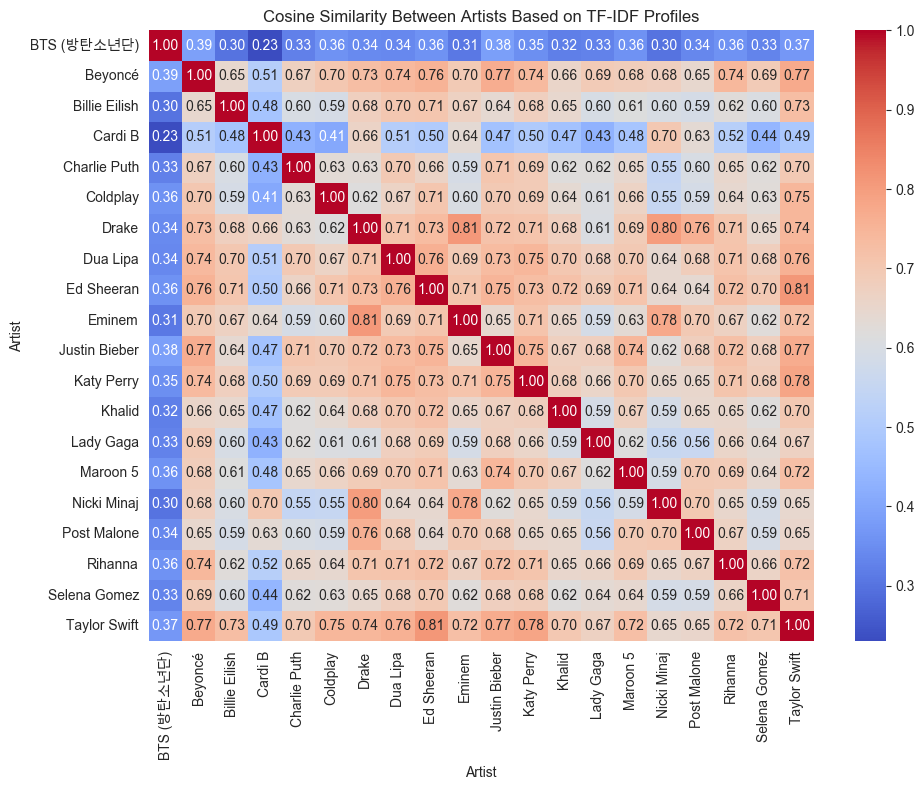

In [59]:
# Visualize artist similarity matrix as a heatmap.
plt.figure(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cosine Similarity Between Artists Based on TF-IDF Profiles")
plt.xlabel("Artist")
plt.ylabel("Artist")
plt.tight_layout()  

## 3. Distinctive Words per Artist

### Collect Distinctive Words

**What this cell does:** Stores top TF-IDF words for each artist in a dictionary.

**What we learn/functionality:** A reusable summary artifact for downstream interpretation or visualization.

In [60]:
# Store top distinctive words per artist in a dictionary.
top_words = {}

for artist in artist_tfidf.index:
    top_words[artist] = (
        artist_tfidf.loc[artist]
        .sort_values(ascending=False)
        .head(15)
        .index
    )

top_words



{'BTS (방탄소년단)': Index(['jungkook', 'jimin', 'jin', 'rm', 'jhope', 'suga', 'yeah', 'oh', 'love',
        'la', 'girl', 'let', 'im', 'know', 'wanna'],
       dtype='str'),
 'Beyoncé': Index(['beyonc', 'love', 'im', 'oh', 'baby', 'let', 'go', 'like', 'girl',
        'dont', 'know', 'got', 'boy', 'see', 'check'],
       dtype='str'),
 'Billie Eilish': Index(['ocean', 'im', 'dont', 'eye', 'like', 'know', 'cant', 'watch', 'love',
        'bloom', 'billie', 'eilish', 'one', 'make', 'rose'],
       dtype='str'),
 'Cardi B': Index(['bitch', 'cardi', 'nigga', 'like', 'im', 'shit', 'dont', 'hoe', 'money',
        'got', 'get', 'pussy', 'fuck', 'aint', 'gon'],
       dtype='str'),
 'Charlie Puth': Index(['charlie', 'puth', 'oh', 'baby', 'dont', 'im', 'youre', 'know', 'one',
        'yeah', 'love', 'anymore', 'wanna', 'tell', 'oooh'],
       dtype='str'),
 'Coldplay': Index(['oh', 'dont', 'light', 'world', 'im', 'come', 'love', 'go', 'see',
        'chris', 'know', 'martin', 'youre', 'gonna', 'let'

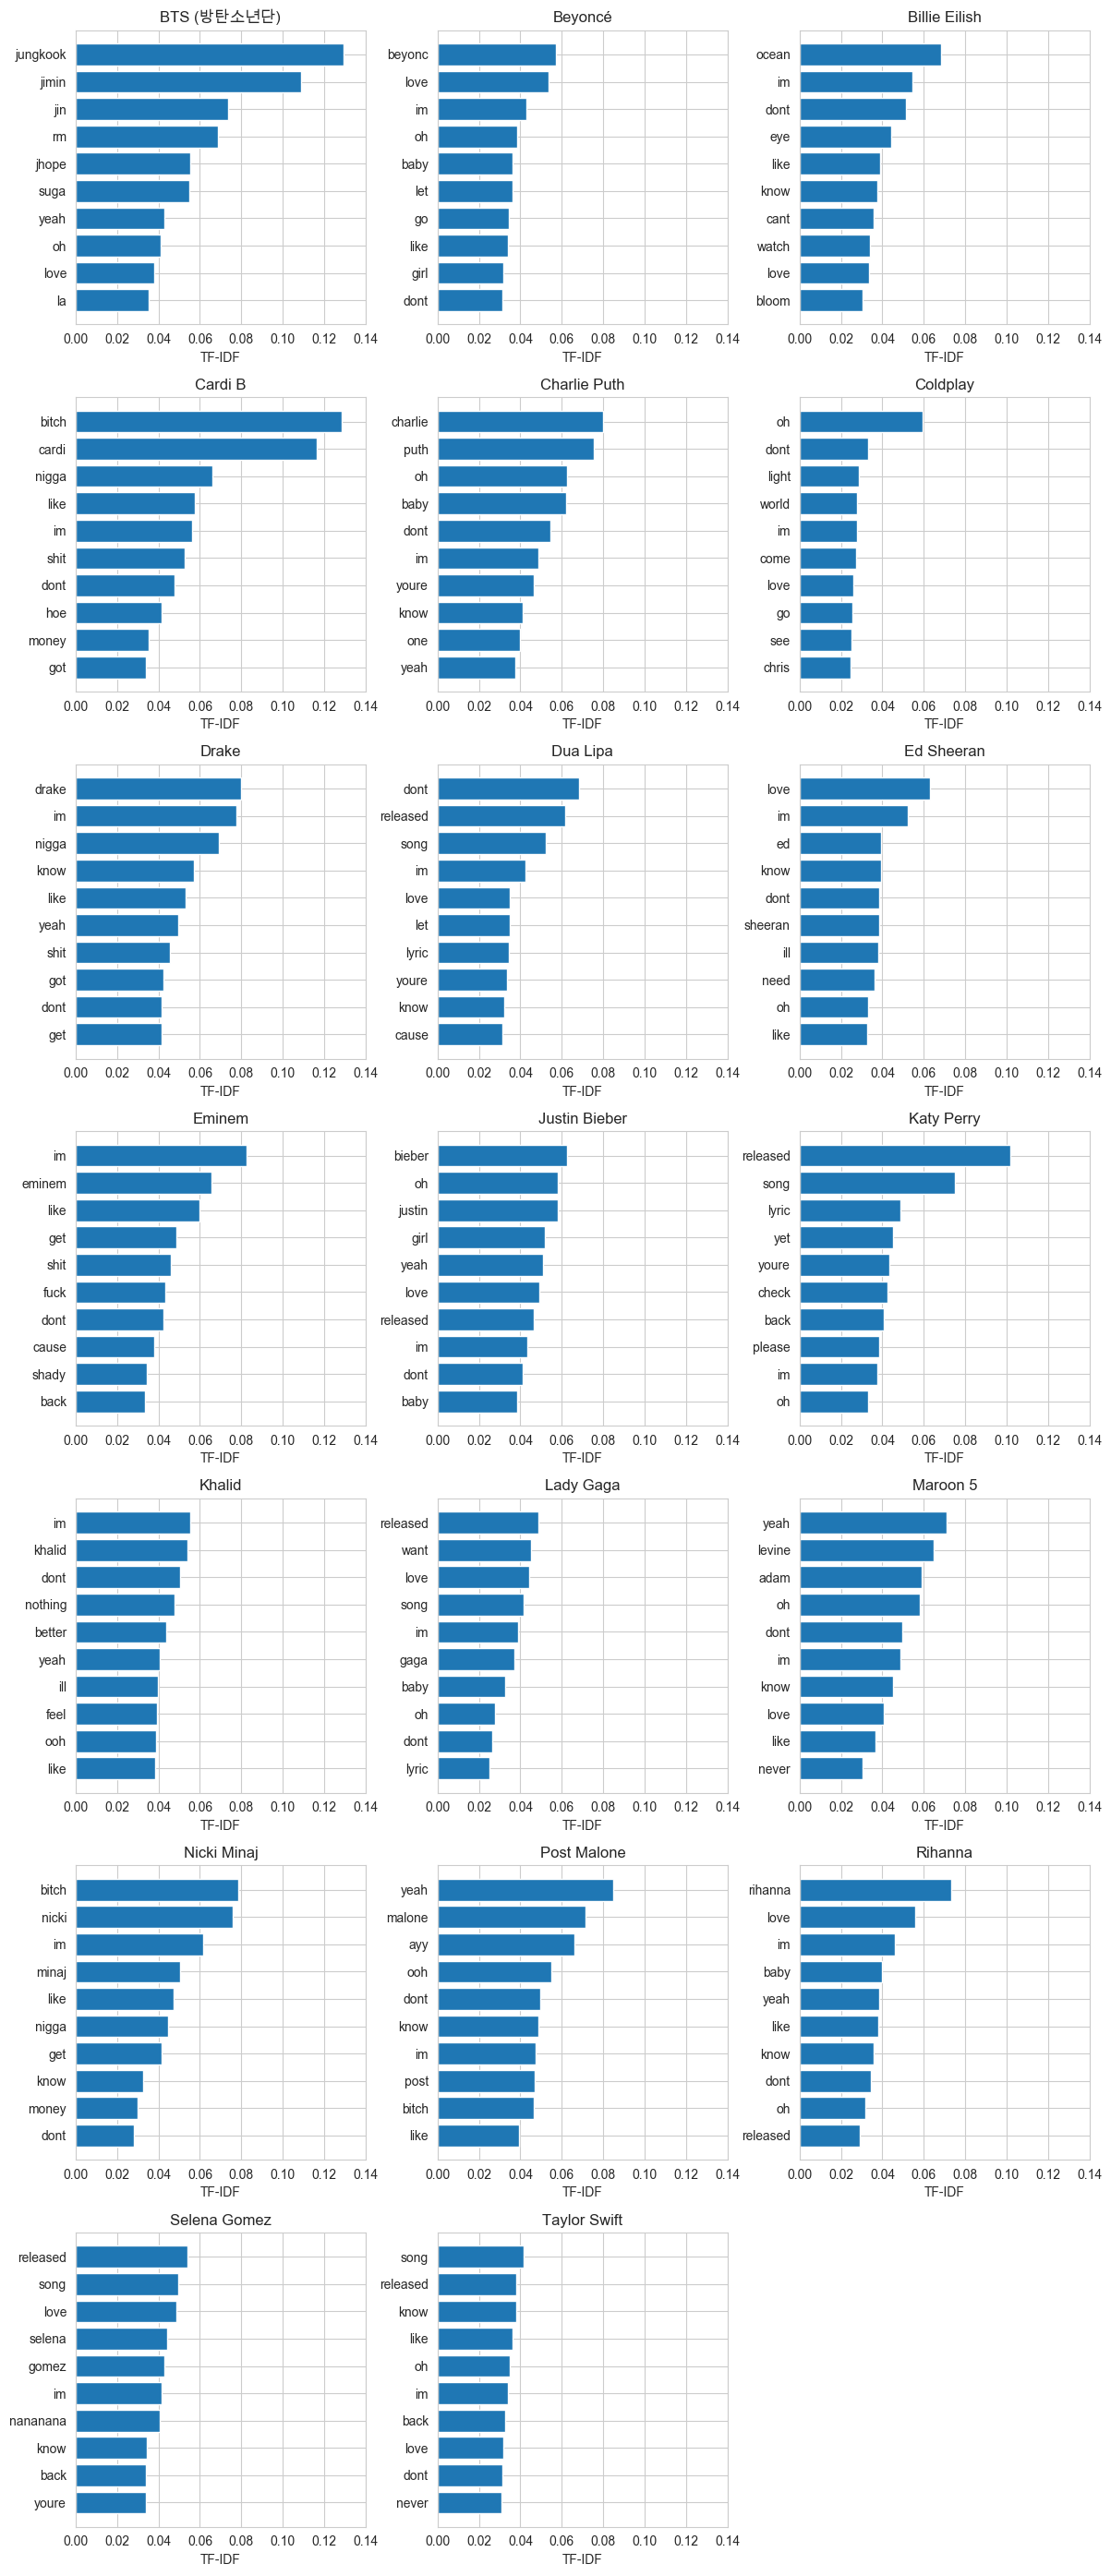

In [63]:
import math

artists = artist_tfidf.index
n = len(artists)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

for i, artist in enumerate(artists):

    top_terms = (
        artist_tfidf.loc[artist]
        .sort_values(ascending=False)
        .head(10)
    )

    axes[i].barh(top_terms.index, top_terms.values)
    axes[i].invert_yaxis()
    axes[i].set_title(artist)
    axes[i].set_xlabel("TF-IDF")
    axes[i].set_xlim(0, 0.14)   # force same scale across all plots

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()